# 04 Decision Memo Figures

This notebook creates the final visuals and summary table used in the decision memo. The previous notebooks performed the data audit, formal experiment analysis, and exploratory segment analysis. This notebook converts those results into concise portfolio-ready evidence for the final recommendation.

## Goal

The final memo should make a clear business recommendation:

- Which campaign should be prioritized?
- How large is the conversion and revenue impact?
- Which segments look most promising for targeting?
- What caveats should be communicated?

The visuals below are intentionally focused. They are designed to support a decision, not to show every analysis table produced during exploration.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import FIGURES_DIR, PROCESSED_DATA_DIR

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

PROJECT_ROOT

WindowsPath('E:/.projects/ab-testing')

## Load Final Analysis Tables

This notebook expects notebooks 02 and 03 to have been run first. Those notebooks create the processed tables used here.

In [2]:
required_files = {
    "impact": PROCESSED_DATA_DIR / "02_practical_impact_summary.csv",
    "proportion_tests": PROCESSED_DATA_DIR / "02_proportion_tests.csv",
    "spend_tests": PROCESSED_DATA_DIR / "02_spend_tests.csv",
    "top_segments": PROCESSED_DATA_DIR / "03_top_segment_opportunities.csv",
    "segment_winners": PROCESSED_DATA_DIR / "03_best_treatment_by_segment.csv",
    "weak_segments": PROCESSED_DATA_DIR / "03_weak_or_risky_segments.csv",
}

missing = [name for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing processed files: " + ", ".join(missing) + ". Run notebooks 02 and 03 first."
    )

impact = pd.read_csv(required_files["impact"])
proportion_tests = pd.read_csv(required_files["proportion_tests"])
spend_tests = pd.read_csv(required_files["spend_tests"])
top_segments = pd.read_csv(required_files["top_segments"])
segment_winners = pd.read_csv(required_files["segment_winners"])
weak_segments = pd.read_csv(required_files["weak_segments"])

impact

,treatment_group,control_conversion_rate,treatment_conversion_rate,conversion_rate_lift,relative_conversion_lift,conversion_lift_ci_low,conversion_lift_ci_high,conversion_p_value,control_spend_per_customer,treatment_spend_per_customer,spend_per_customer_lift,relative_spend_lift,spend_lift_ci_low,spend_lift_ci_high,spend_p_value,estimated_incremental_revenue_per_100k_customers,estimated_incremental_conversions_per_100k_customers
0,Mens E-Mail,0.0057,0.0125,0.0068,1.1884,0.0050,0.0086,0.0000,0.6528,1.4226,0.7698,1.1793,0.4937,1.0610,0.0000,76982.7156,680.5007
1,Womens E-Mail,0.0057,0.0088,0.0031,0.5433,0.0015,0.0047,0.0002,0.6528,1.0772,0.4244,0.6502,0.1672,0.6776,0.0011,42441.2216,311.1058


## Final Recommendation Summary Table

This table condenses the core evidence into a format suitable for the final memo.

In [3]:
recommendation_summary = impact[[
    "treatment_group",
    "control_conversion_rate",
    "treatment_conversion_rate",
    "conversion_rate_lift",
    "relative_conversion_lift",
    "conversion_p_value",
    "control_spend_per_customer",
    "treatment_spend_per_customer",
    "spend_per_customer_lift",
    "spend_p_value",
    "estimated_incremental_revenue_per_100k_customers",
    "estimated_incremental_conversions_per_100k_customers",
]].copy()

recommendation_summary["recommendation_rank"] = recommendation_summary["spend_per_customer_lift"].rank(ascending=False, method="first").astype(int)
recommendation_summary = recommendation_summary.sort_values("recommendation_rank")
recommendation_summary.to_csv(PROCESSED_DATA_DIR / "04_final_recommendation_summary.csv", index=False)
recommendation_summary

,treatment_group,control_conversion_rate,treatment_conversion_rate,conversion_rate_lift,relative_conversion_lift,conversion_p_value,control_spend_per_customer,treatment_spend_per_customer,spend_per_customer_lift,spend_p_value,estimated_incremental_revenue_per_100k_customers,estimated_incremental_conversions_per_100k_customers,recommendation_rank
0,Mens E-Mail,0.0057,0.0125,0.0068,1.1884,0.0000,0.6528,1.4226,0.7698,0.0000,76982.7156,680.5007,1
1,Womens E-Mail,0.0057,0.0088,0.0031,0.5433,0.0002,0.6528,1.0772,0.4244,0.0011,42441.2216,311.1058,2


## Figure 1: Conversion Lift With Confidence Intervals

The primary metric is conversion rate. This chart shows absolute lift versus the no-email control group, with 95% confidence intervals.

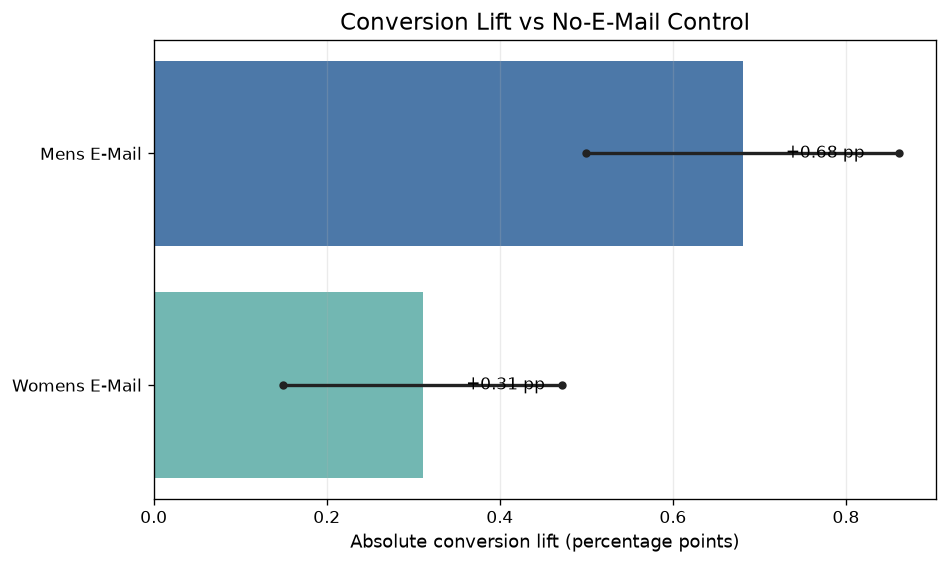

WindowsPath('E:/.projects/ab-testing/reports/figures/final_conversion_lift_ci.png')

In [4]:
conversion = proportion_tests.loc[proportion_tests["metric"].eq("Conversion rate")].copy()
conversion["lift_pp"] = conversion["absolute_lift"] * 100
conversion["ci_low_pp"] = conversion["ci_low"] * 100
conversion["ci_high_pp"] = conversion["ci_high"] * 100
conversion = conversion.sort_values("lift_pp", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = ["#72B7B2" if "Womens" in group else "#4C78A8" for group in conversion["treatment_group"]]
ax.barh(conversion["treatment_group"], conversion["lift_pp"], color=colors)
for i, row in conversion.reset_index(drop=True).iterrows():
    ax.plot([row["ci_low_pp"], row["ci_high_pp"]], [i, i], color="#222222", linewidth=2)
    ax.scatter([row["ci_low_pp"], row["ci_high_pp"]], [i, i], color="#222222", s=16)
    ax.text(row["lift_pp"] + 0.05, i, f"+{row['lift_pp']:.2f} pp", va="center")
ax.axvline(0, color="#222222", linewidth=1)
ax.set_title("Conversion Lift vs No-E-Mail Control")
ax.set_xlabel("Absolute conversion lift (percentage points)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
conversion_fig = FIGURES_DIR / "final_conversion_lift_ci.png"
plt.savefig(conversion_fig, bbox_inches="tight")
plt.show()
conversion_fig

## Figure 2: Spend Per Customer Lift

Spend per customer translates the experiment into direct business impact. This chart uses the bootstrap confidence intervals from notebook 02.

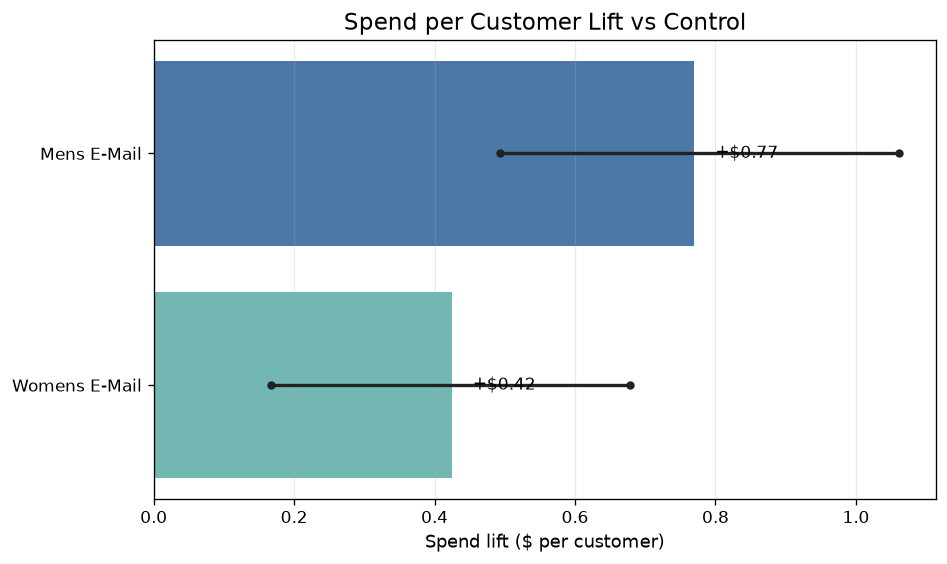

WindowsPath('E:/.projects/ab-testing/reports/figures/final_spend_lift_ci.png')

In [5]:
spend = spend_tests.copy().sort_values("absolute_lift", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = ["#72B7B2" if "Womens" in group else "#4C78A8" for group in spend["treatment_group"]]
ax.barh(spend["treatment_group"], spend["absolute_lift"], color=colors)
for i, row in spend.reset_index(drop=True).iterrows():
    ax.plot([row["ci_low"], row["ci_high"]], [i, i], color="#222222", linewidth=2)
    ax.scatter([row["ci_low"], row["ci_high"]], [i, i], color="#222222", s=16)
    ax.text(row["absolute_lift"] + 0.03, i, f"+${row['absolute_lift']:.2f}", va="center")
ax.axvline(0, color="#222222", linewidth=1)
ax.set_title("Spend per Customer Lift vs Control")
ax.set_xlabel("Spend lift ($ per customer)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
spend_fig = FIGURES_DIR / "final_spend_lift_ci.png"
plt.savefig(spend_fig, bbox_inches="tight")
plt.show()
spend_fig

## Figure 3: Estimated Revenue Impact

This converts spend lift into an estimated revenue impact per 100,000 targeted customers.

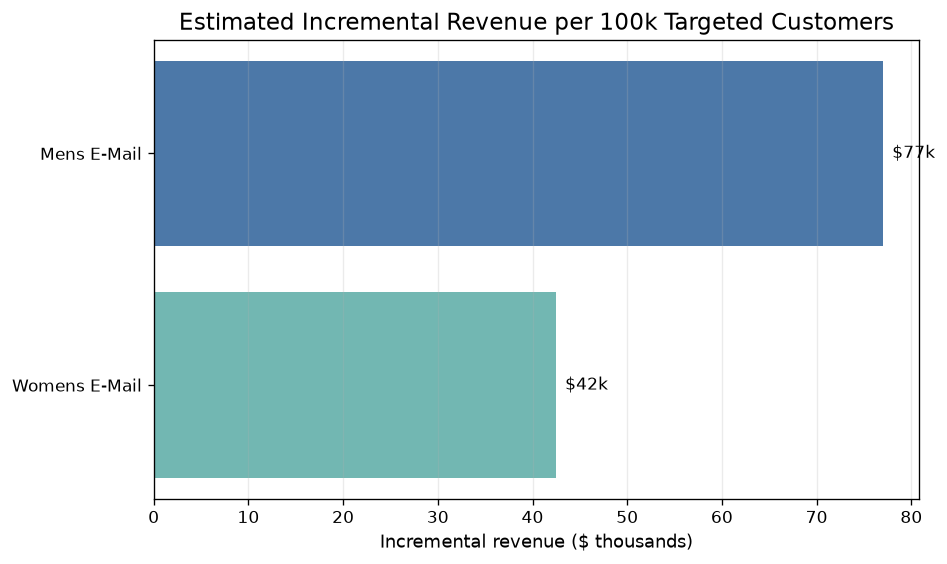

WindowsPath('E:/.projects/ab-testing/reports/figures/final_revenue_impact.png')

In [6]:
revenue = impact.sort_values("estimated_incremental_revenue_per_100k_customers", ascending=True).copy()
revenue["revenue_k"] = revenue["estimated_incremental_revenue_per_100k_customers"] / 1000

fig, ax = plt.subplots(figsize=(8, 4.8))
colors = ["#72B7B2" if "Womens" in group else "#4C78A8" for group in revenue["treatment_group"]]
ax.barh(revenue["treatment_group"], revenue["revenue_k"], color=colors)
for i, value in enumerate(revenue["revenue_k"]):
    ax.text(value + 1, i, f"${value:.0f}k", va="center")
ax.set_title("Estimated Incremental Revenue per 100k Targeted Customers")
ax.set_xlabel("Incremental revenue ($ thousands)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
revenue_fig = FIGURES_DIR / "final_revenue_impact.png"
plt.savefig(revenue_fig, bbox_inches="tight")
plt.show()
revenue_fig

## Figure 4: Top Targeting Opportunities

This chart uses the exploratory segment analysis to identify high-value targeting opportunities. The values are adjusted by segment size, so they represent expected revenue per 100,000 total customers if only that segment were targeted.

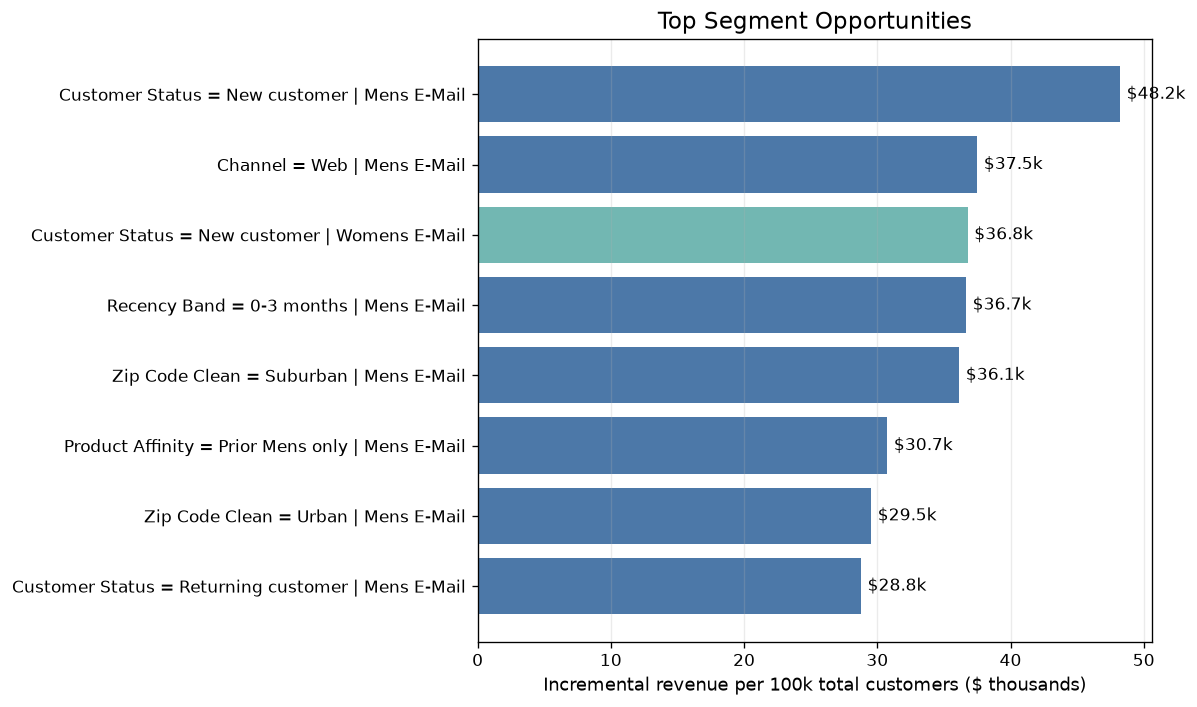

WindowsPath('E:/.projects/ab-testing/reports/figures/final_top_segment_opportunities.png')

In [7]:
segments = top_segments.head(8).copy()
segments["label"] = segments["segment_variable"].str.replace("_", " ").str.title() + " = " + segments["segment_value"] + " | " + segments["treatment_group"]
segments["revenue_k"] = segments["incremental_revenue_per_100k_total_customers_if_targeted"] / 1000
segments = segments.sort_values("revenue_k")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#72B7B2" if "Womens" in group else "#4C78A8" for group in segments["treatment_group"]]
ax.barh(segments["label"], segments["revenue_k"], color=colors)
for i, value in enumerate(segments["revenue_k"]):
    ax.text(value + 0.5, i, f"${value:.1f}k", va="center")
ax.set_title("Top Segment Opportunities")
ax.set_xlabel("Incremental revenue per 100k total customers ($ thousands)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
segment_fig = FIGURES_DIR / "final_top_segment_opportunities.png"
plt.savefig(segment_fig, bbox_inches="tight")
plt.show()
segment_fig

## Final Evidence Snapshot

This section creates a short text summary that can be copied into the decision memo.

In [8]:
best = recommendation_summary.iloc[0]
second = recommendation_summary.iloc[1]
top_segment = top_segments.iloc[0]
weak_count = len(weak_segments)
mens_wins = int((segment_winners["treatment_group"] == "Mens E-Mail").sum())
womens_wins = int((segment_winners["treatment_group"] == "Womens E-Mail").sum())

summary_lines = [
    f"Recommended treatment: {best['treatment_group']}",
    f"Conversion lift: {best['conversion_rate_lift']:.2%} absolute ({best['relative_conversion_lift']:.1%} relative)",
    f"Spend lift: ${best['spend_per_customer_lift']:.2f} per customer",
    f"Estimated revenue lift: ${best['estimated_incremental_revenue_per_100k_customers']:,.0f} per 100,000 targeted customers",
    f"Top targeting opportunity: {top_segment['segment_variable']} = {top_segment['segment_value']} with {top_segment['treatment_group']}",
    f"Segment winner count: Mens E-Mail {mens_wins}, Womens E-Mail {womens_wins}",
    f"Weak or risky stable segment-treatment combinations: {weak_count}",
]
print("\n".join(summary_lines))

Recommended treatment: Mens E-Mail
Conversion lift: 0.68% absolute (118.8% relative)
Spend lift: $0.77 per customer
Estimated revenue lift: $76,983 per 100,000 targeted customers
Top targeting opportunity: customer_status = New customer with Mens E-Mail
Segment winner count: Mens E-Mail 17, Womens E-Mail 4
Weak or risky stable segment-treatment combinations: 2


## Notebook Outputs

This notebook writes:

- `data/processed/04_final_recommendation_summary.csv`
- `reports/figures/final_conversion_lift_ci.png`
- `reports/figures/final_spend_lift_ci.png`
- `reports/figures/final_revenue_impact.png`
- `reports/figures/final_top_segment_opportunities.png`

These figures are intentionally tracked in Git because they support the final portfolio memo.